#Python Week-2
#Colab
#Anaconda
#Jupyter



In [ ]:
a = 10
b = 11
print(a+b)

21


In [ ]:
strAAA = 'hello world!!!'
print(strAAA)

hello world!!!


=== 硬體環境檢查 ===
Python 版本: 3.13.15
PyTorch 版本: 2.11.0+cpu
CUDA 可用: False
⚠️ 未偵測到 GPU，請至『執行階段』->『變更執行階段類型』-> 選擇『T4 GPU』
----------------------------------------
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 60.9 MB/s eta 0:00:00
=== 前 5 筆模擬資料 ===


/tmp/ipykernel_1384/3173124266.py:36: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start='2024-01-01', periods=12, freq='M')


,月份,營收(萬),用戶數
0,2024-01,5524.8,10207
1,2024-02,6017.9,10349
2,2024-03,6550.3,10498
3,2024-04,7126.5,10681
4,2024-05,7614.8,10850


/tmp/ipykernel_1384/3173124266.py:65: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1384/3173124266.py:65: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1384/3173124266.py:65: UserWarning: Glyph 29151 (\N{CJK UNIFIED IDEOGRAPH-71DF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1384/3173124266.py:65: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1384/3173124266.py:65: UserWarning: Glyph 33836 (\N{CJK UNIFIED IDEOGRAPH-842C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1384/3173124266.py:65: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1384/3173124266.py:65: UserWarning: Glyph 25142 (\N{CJK UNIFIED IDEOGRAPH-6236}

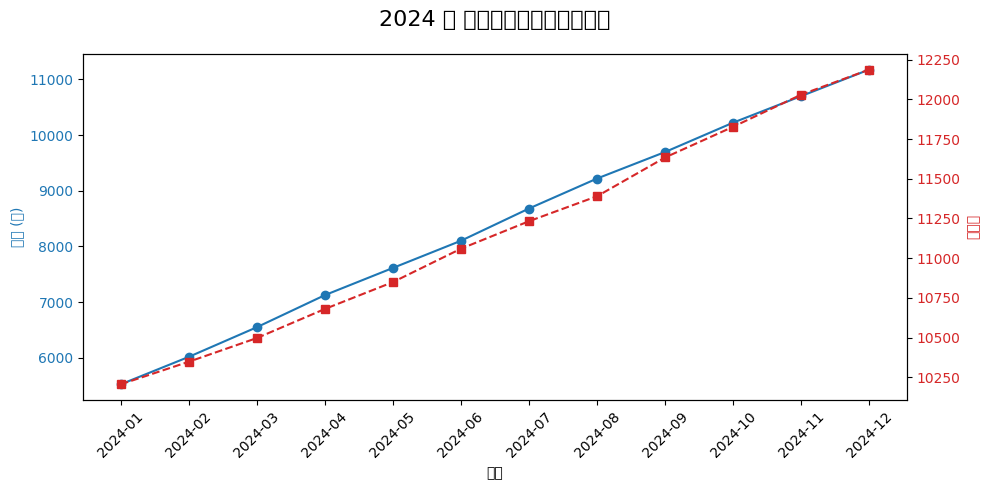

=== 互動式圖表 (滑鼠移上去看數值、可縮放、可下載圖片) ===


=== 顯示網路圖片範例 (Python Logo) ===



✅ 所有程式碼執行完畢！


In [ ]:
# ==========================================
# 1. 環境檢查：確認 Colab 是否分配到 GPU (免費版通常有 T4)
# ==========================================
import torch
print("=== 硬體環境檢查 ===")
print(f"Python 版本: {__import__('sys').version.split()[0]}")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 型號: {torch.cuda.get_device_name(0)}")
    print(f"GPU 記憶體: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ 未偵測到 GPU，請至『執行階段』->『變更執行階段類型』-> 選擇『T4 GPU』")
print("-" * 40)

# ==========================================
# 2. 安裝套件 (Colab 預裝很多，但 plotly 可能要裝新版)
# ==========================================
# 靜默安裝，不顯示冗長 log
!pip install -q plotly -U

# ==========================================
# 3. 產生模擬資料 & 靜態圖表
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 設定中文字體 (Colab 預設支援 Noto Sans CJK)
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False

# 產生模擬資料：模擬「某科技公司近 12 個月營收與使用者成長」
np.random.seed(42)
months = pd.date_range(start='2024-01-01', periods=12, freq='M')
revenue = np.cumsum(np.random.normal(500, 50, 12)) + 5000 # 累積營收
users = np.cumsum(np.random.normal(200, 30, 12)) + 10000   # 累積用戶

df = pd.DataFrame({
    '月份': months.strftime('%Y-%m'),
    '營收(萬)': revenue.round(1),
    '用戶數': users.astype(int)
})

print("=== 前 5 筆模擬資料 ===")
display(df.head()) # Colab 專用 display()，顯示較美觀的表格

# --- Matplotlib / Seaborn 靜態雙軸圖 ---
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('月份')
ax1.set_ylabel('營收 (萬)', color=color)
ax1.plot(df['月份'], df['營收(萬)'], color=color, marker='o', label='營收')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('用戶數', color=color)
ax2.plot(df['月份'], df['用戶數'], color=color, marker='s', linestyle='--', label='用戶數')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('2024 年 模擬營收與用戶成長趨勢', fontsize=16, pad=20)
fig.tight_layout()
plt.show()

# ==========================================
# 4. 互動式圖表 - 重頭戲
# ==========================================
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("=== 互動式圖表 (滑鼠移上去看數值、可縮放、可下載圖片) ===")

# 建立雙軸子圖
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 營收長條圖
fig.add_trace(
    go.Bar(x=df['月份'], y=df['營收(萬)'], name='營收(萬)', marker_color='#1f77b4', opacity=0.7),
    secondary_y=False,
)

# 用戶數折線圖
fig.add_trace(
    go.Scatter(x=df['月份'], y=df['用戶數'], name='用戶數', mode='lines+markers',
               line=dict(color='#ff7f0e', width=3), marker=dict(size=8)),
    secondary_y=True,
)

# 版面美化
fig.update_layout(
    title_text='📈 互動式：營收長條圖 + 用戶成長折線圖',
    template='plotly_white', # 乾淨白底
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    hovermode='x unified',   # 同一個 X 軸顯示所有數值
    height=500
)

fig.update_xaxes(title_text="月份", tickangle=45)
fig.update_yaxes(title_text="營收 (萬)", secondary_y=False, showgrid=False)
fig.update_yaxes(title_text="用戶數", secondary_y=True, showgrid=False)

# 在 Colab 顯示互動圖
fig.show()

# ==========================================
# 5. 顯示本地圖片 / 網路圖片
# ==========================================
from IPython.display import Image, display
print("=== 顯示網路圖片範例 (Python Logo) ===")
display(Image(url='https://www.python.org/static/community_logos/python-logo-generic.svg', width=300))

print("\n✅ 所有程式碼執行完畢！")
